### Rainfall Comparison: WRF vs. NCEP Stage IV

This notebook generates figures that compare simulated WRF rainfall and NCEP Stage IV rainfall.

In [1]:
import netCDF4
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import subprocess
import matplotlib as mpl
import xarray as xr

### Datahandling

/home/colinwelty/.conda/envs/home/lib/python3.9/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.31.0 or higher is recommended. You are running version 2.30.2
  warnings.warn(


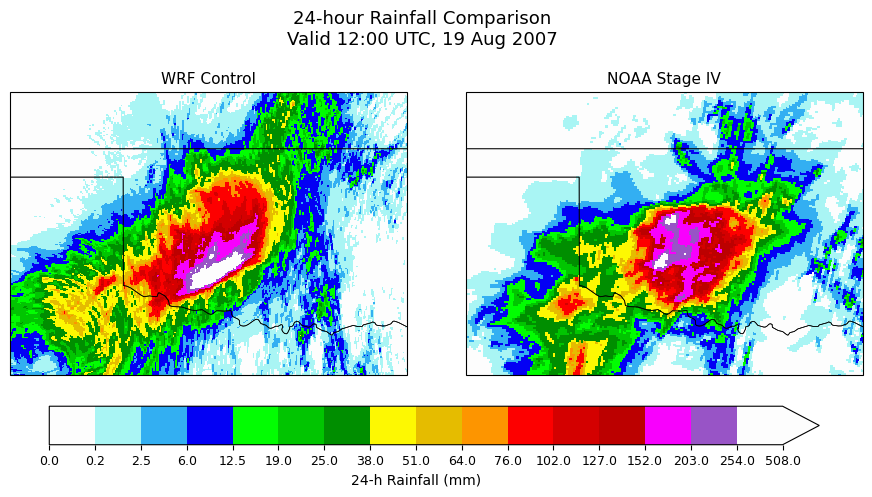

In [2]:

# --- File paths ---
wrf_file_start = '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/colin/erin/test/output/raw_original/wrfout_d02_2007-08-18_12:00:00'
wrf_file_end   = '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/colin/erin/test/output/raw_original/wrfout_d02_2007-08-19_12:00:00'
stageIV_file   = '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/colin60186/ST4.2007081912.24h'

# --- Load WRF data ---
wrf_start = Dataset(wrf_file_start)
wrf_end   = Dataset(wrf_file_end)

lon = wrf_end.variables['XLONG'][0]
lat = wrf_end.variables['XLAT'][0]

precip_end   = wrf_end.variables['RAINC'][0] + wrf_end.variables['RAINNC'][0]
precip_start = wrf_start.variables['RAINC'][0] + wrf_start.variables['RAINNC'][0]
precip_24h = precip_end - precip_start

# Coarsen WRF grid for plotting (optional)
coarsening_factor = 2
coarse_lon = lon[::coarsening_factor, ::coarsening_factor]
coarse_lat = lat[::coarsening_factor, ::coarsening_factor]
coarse_precip = precip_24h[::coarsening_factor, ::coarsening_factor]

# --- Load Stage IV data ---
stageIV = xr.open_dataset(stageIV_file, engine='cfgrib')
rlon = stageIV['longitude'].values
rlat = stageIV['latitude'].values
tp = stageIV['tp'].values

# --- Colors ---
nws_precip_colors = [
    "#fdfdfd","#a9f5f4","#33aff2","#0300f4","#02fd02","#01c501","#008e00",
    "#fdf802","#e5bc00","#fd9500","#fd0000","#d40000","#bc0000",
    "#f800fd","#9854c6","#fdfdfd"
]
cmap = mpl.colors.ListedColormap(nws_precip_colors)
levels = [0.0, 0.25, 2.5, 6, 12.5, 19, 25, 38, 51, 64, 76, 102, 127,
          152, 203, 254, 508]
norm = mpl.colors.BoundaryNorm(levels, cmap.N)

# --- Plot ---
# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Adjust spacing between panels
plt.subplots_adjust(wspace=0.15)

# Titles and data list
titles = ['WRF Control', 'NOAA Stage IV']
data_list = [(coarse_lon, coarse_lat, coarse_precip), (rlon, rlat, tp)]

# Expanded extent
extent = [-102, -95, 33, 38]

for ax, (lon_data, lat_data, precip_data), title in zip(axes, data_list, titles):
    pcm = ax.pcolormesh(lon_data, lat_data, precip_data, cmap=cmap, norm=norm)
    ax.set_title(title, fontsize=11, fontweight='normal')
    ax.set_xlabel("Longitude", fontsize=9)
    ax.set_ylabel("Latitude", fontsize=9)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', linewidth=0.5)
    ax.grid(True, linestyle='--', alpha=0.4)

# Shared colorbar
cbar = fig.colorbar(pcm, ax=axes, orientation='horizontal', fraction=0.1, pad=0.08,
                    extend='max', ticks=levels)
cbar.set_label("24-h Rainfall (mm)", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Supertitle
fig.suptitle("24-hour Rainfall Comparison\nValid 12:00 UTC, 19 Aug 2007",
             fontsize=13, fontweight='normal')

# Save figure
plt.savefig("wrf_stageIV_24h.pdf", dpi=600, bbox_inches='tight')
plt.show()
plt.close(fig)

AttributeError: 'numpy.ndarray' object has no attribute 'imshow'

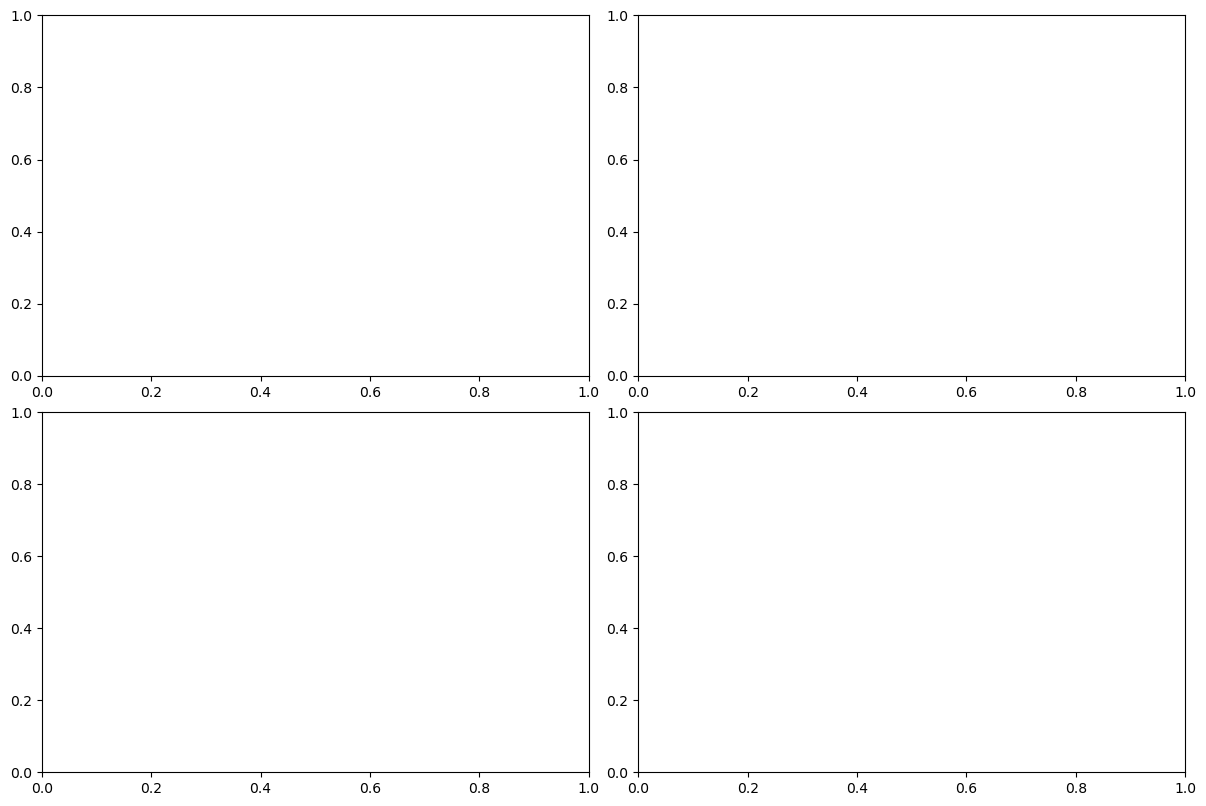

In [ ]:
directory = '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/colin/erin/test/output/raw_original/'
prefix = 'wrfout_d02'
timeStep = '08-19_12:00:00'
timeStepSub = '08-19_09:00:00'
directory_d = '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/colin/erin/test/output/raw_diurnal/'
prefix_d = 'wrfout_d02'
timeStep_d = '08-19_12:00:00'
timeStepSub_d = '08-19_09:00:00'

### Manuscript Figure

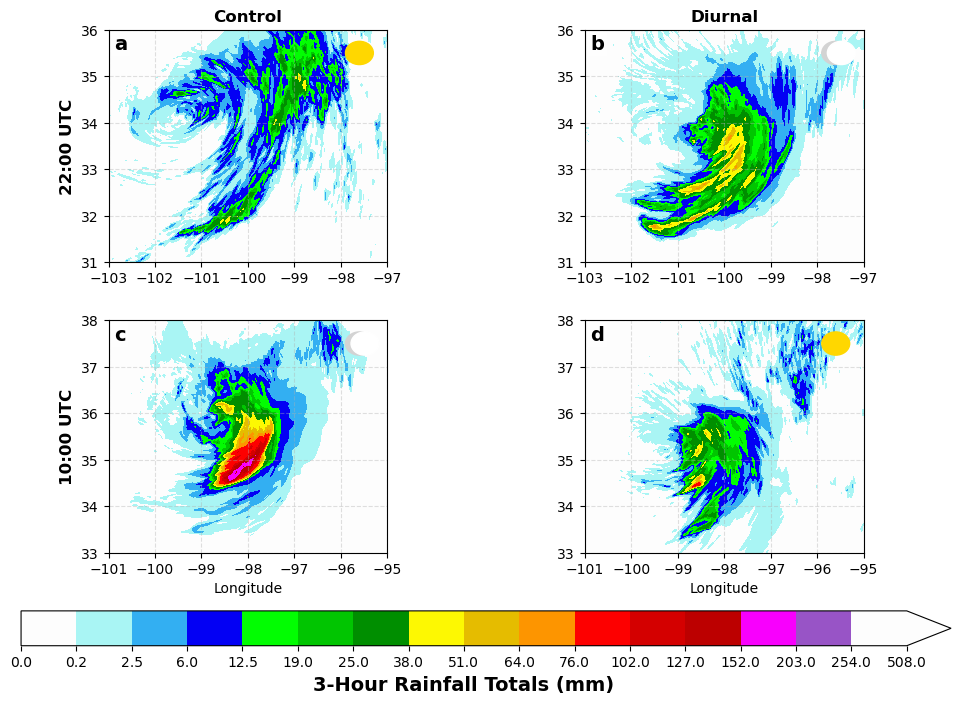

In [5]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from datetime import datetime, timedelta

def plot_control_vs_diurnal_4panel(
    directory, directory_d, prefix, prefix_d,
    end_times, savepath,
    extent=None  # either [lonmin,lonmax,latmin,latmax] or [[...],[...]] per row
):
    """
    4-panel plot of 3-h rainfall totals.
      - Left column: Control
      - Right column: Diurnal
      - Top row: accumulation ending at end_times[0]
      - Bottom row: accumulation ending at end_times[1]

    Parameters
    ----------
    directory, directory_d : str
        Paths to control/diurnal files (directories ending with '/')
    prefix, prefix_d : str
        File prefixes (e.g., 'wrfout_d02')
    end_times : list[str]
        Two strings "MM-DD_HH:MM:SS" for the END of the 3-h accumulation
    savepath : str
        Output image path
    extent : list[float] or list[list[float]], optional
        If a single list -> applied to both rows.
        If two lists -> [extent_for_top_row, extent_for_bottom_row]
        Each extent is [lonmin, lonmax, latmin, latmax].
    """

    # --- helpers ---
    def get_precip(directory, prefix, end_time):
        """
        Return 3h accumulation (end_time - 3h -> end_time) and lon/lat grids.
        Uses exact path: {directory}{prefix}_2007-{end_time}
        """
        end_dt = datetime.strptime("2007-" + end_time, "%Y-%m-%d_%H:%M:%S")
        start_dt = end_dt - timedelta(hours=3)
        f1 = Dataset(f"{directory}{prefix}_2007-{end_time}")
        f0 = Dataset(f"{directory}{prefix}_2007-{start_dt.strftime('%m-%d_%H:%M:%S')}")
        rainc1, rainnc1 = f1.variables["RAINC"][:],  f1.variables["RAINNC"][:]
        rainc0, rainnc0 = f0.variables["RAINC"][:],  f0.variables["RAINNC"][:]
        lons = f1.variables["XLONG"][0]
        lats = f1.variables["XLAT"][0]
        f1.close(); f0.close()
        acc = (rainc1 + rainnc1)[0] - (rainc0 + rainnc0)[0]
        return acc, lons, lats

    def add_icon(ax, which):
        """Vector sun/moon icon at top-right of the axes."""
        if which == "sun":
            sun = plt.Circle((0.9, 0.9), 0.05, color="gold",
                             transform=ax.transAxes, zorder=10)
            ax.add_patch(sun)
        elif which == "moon":
            base = plt.Circle((0.9, 0.9), 0.05, color="lightgray",
                              transform=ax.transAxes, zorder=10)
            cut  = plt.Circle((0.92, 0.9), 0.05, color="white",
                              transform=ax.transAxes, zorder=11)
            ax.add_patch(base); ax.add_patch(cut)

    # day/night mapping per your spec:
    # Control: 00Z = day (sun), 12Z = night (moon). Diurnal is inverted.
    def which_icon(column_name, end_time_str):
        hhmmss = end_time_str[-8:]
        if hhmmss == "22:00:00":
            return "sun" if column_name == "Control" else "moon"
        if hhmmss == "10:00:00":
            return "moon" if column_name == "Control" else "sun"
        return None  # no icon for other times
    
    def add_panel_label(ax, label):
        ax.text(
            0.02, 0.98, label,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=14, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=2),
            zorder=20
        )

    # --- Colormap (NWS) ---
    nws_precip_colors = [
        "#fdfdfd","#a9f5f4","#33aff2","#0300f4","#02fd02","#01c501","#008e00",
        "#fdf802","#e5bc00","#fd9500","#fd0000","#d40000","#bc0000","#f800fd",
        "#9854c6","#fdfdfd"
    ]
    cmap = mpl.colors.ListedColormap(nws_precip_colors)
    levels = [0.0, 0.25, 2.5, 6, 12.5, 19, 25, 38, 51, 64, 76, 102, 127,
              152, 203, 254, 508]
    norm = mpl.colors.BoundaryNorm(levels, len(levels)-1)

    # normalize extent argument
    if extent is not None and isinstance(extent[0], (int, float, np.floating)):
        extent = [extent, extent]  # same crop for both rows

    import matplotlib.gridspec as gridspec
    fig = plt.figure(figsize=(12, 8))

    # Make 3 rows (2 for panels, 1 skinny for colorbar)
    gs = gridspec.GridSpec(3, 2, figure=fig,
                        height_ratios=[1, 1, 0.15],  # last row = colorbar
                        wspace=0.05, hspace=0.35)   # horizontal + vertical spacing

    # Panels
    axes = np.array([
        [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])],
        [fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])]
    ])

    # Colorbar axis spans bottom row
    cax = fig.add_subplot(gs[2, :])
    cols = ["Control", "Diurnal"]

    # --- build panels ---
    last_pcm = None
    for i, end_time in enumerate(end_times):
        # compute both runs for this end_time
        precip_c, lons, lats = get_precip(directory,   prefix,   end_time)
        precip_d, _,    _    = get_precip(directory_d, prefix_d, end_time)

        lonmin, lonmax = float(lons.min()), float(lons.max())
        latmin, latmax = float(lats.min()), float(lats.max())

        for j, (data, colname) in enumerate(zip([precip_c, precip_d], cols)):
            ax = axes[i, j]
            # Panel lettering order: a b / c d
            panel_letters = np.array([["a", "b"],
                                    ["c", "d"]])

            add_panel_label(ax, panel_letters[i, j])
            last_pcm = ax.imshow(
                data, origin="lower", cmap=cmap, norm=norm,
                extent=[lonmin, lonmax, latmin, latmax],
                #aspect="auto"
            )

            # optional zoom per row
            if extent is not None:
                ax.set_xlim(extent[i][0], extent[i][1])
                ax.set_ylim(extent[i][2], extent[i][3])

            # --- Label only outer edges (column headers on top row; row time on left) ---
            if i == 0:  # top row column titles
                ax.set_title(colname, fontsize=12, fontweight="bold")
            if j == 0:  # left column row labels
                ax.set_ylabel(f"{end_time[-8:-3]} UTC", fontsize=12, fontweight="bold")

            # x labels only on bottom row to de-clutter
            if i == 1:
                ax.set_xlabel("Longitude")

            ax.grid(True, linestyle="--", alpha=0.4)

            # icons
            icon = which_icon(colname, end_time)
            if icon:
                add_icon(ax, icon)

    cbar = fig.colorbar(last_pcm, cax=cax,
                    orientation="horizontal", extend="max", ticks=levels)
    
    cbar.set_label("3-Hour Rainfall Totals (mm)", fontsize=14, fontweight="bold")
    cbar.ax.tick_params(labelsize=10)

    fig.savefig(savepath, dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# -------- Example call (paths/filenames unchanged) --------
plot_control_vs_diurnal_4panel(
    directory="/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/colin/erin/test/output/raw_original/",
    directory_d="/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/colin/erin/test/output/raw_diurnal/",
    prefix="wrfout_d02",
    prefix_d="wrfout_d02",
    end_times=["08-18_22:00:00", "08-19_10:00:00"],
    savepath="diurnalrainfallcompare_4panel.png",
    extent=[[-103, -97, 31, 36],   # crop for top row (00 UTC)
            [-101, -95, 33, 38]]   # crop for bottom row (12 UTC)
)